In [4]:

# loading saved embeddings
# and seperating embeddings and paths
import torch
import numpy as np 
import torch.nn.functional as F

data=torch.load("SimSearch_0_image_embeddings.pt") # loading iamge embeddings
embeddings = data["SimSearch_0_embeddings"] # (N,D)
paths = data["SimSearch_0_paths"]


In [6]:
# converting list 'embeddings' into tensor 'embeddings' and normalizing it
if isinstance(embeddings, list):
    embeddings = np.array(embeddings)

embeddings = torch.tensor(embeddings, dtype=torch.float32)
embeddings = F.normalize(embeddings, dim=1) # normalizing embeddings

print(embeddings.shape)
print(embeddings)

torch.Size([3014, 1, 256])
tensor([[[-1.,  1., -1.,  ...,  1., -1., -1.]],

        [[-1.,  1.,  1.,  ...,  1.,  1., -1.]],

        [[-1.,  1.,  1.,  ...,  1., -1., -1.]],

        ...,

        [[ 1.,  1.,  1.,  ...,  1.,  1.,  1.]],

        [[-1.,  1., -1.,  ...,  1.,  1.,  1.]],

        [[-1.,  1., -1.,  ...,  1.,  1.,  1.]]])


C:\Users\USER\AppData\Local\Temp\ipykernel_16584\2815268350.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings = torch.tensor(embeddings, dtype=torch.float32)


In [8]:
# removing extra dimensions from embeddings
embeddings = embeddings.squeeze()
print(embeddings.shape)

torch.Size([3014, 256])


**Reducer for embedding dimension**

In [9]:

import umap
import pickle

# reducer of embedding size
reducer_2D = umap.UMAP(n_components=2, random_state=42) 
reducer_3D = umap.UMAP(n_components=3, random_state=42)


c:\Users\USER\simsearch\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Cluster IDs**

In [12]:
from sklearn.cluster import KMeans  # using k means clustring

kmeans = KMeans(n_clusters=5, random_state=42)
# cluster ids for visualization of clusters
cluster_ids = kmeans.fit_predict(embeddings)
# print(cluster_ids)

**For 2D visualization**

In [ ]:
# # DON'T RUN TWICE
# # creating a 2D embeddings and savign the .pkl file of reducer
# embeddings_2D = reducer_2D.fit_transform(embeddings.cpu().numpy())  # 2D representation of embeddings

# np.save("embeddings_2D.npy", embeddings_2D)  # saving 2D embedding
# pickle.dump(reducer_2D, open("umap_2D.pkl", "wb")) # saving reducer (used to reduce dimension)

c:\Users\USER\simsearch\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<module 'matplotlib.pyplot' from 'c:\\Users\\USER\\simsearch\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

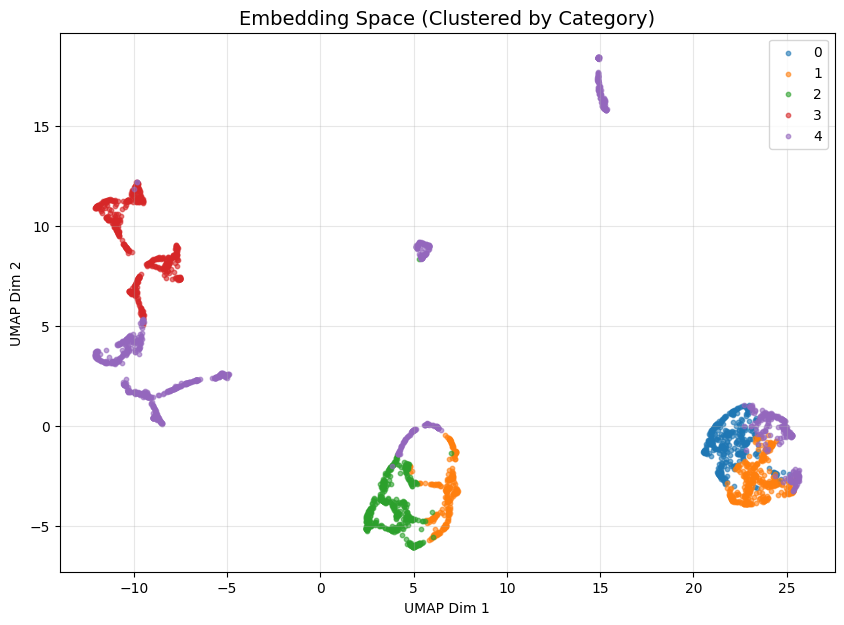

In [14]:

# plotting clusters in 2D space
import numpy as np
import matplotlib.pyplot as plt


def plot_clusters(embeddings_2D, cluster_ids):
    plt.figure(figsize=(10, 7))

    cluster_ids= np.array(cluster_ids) # converting cluster ids into array
    unique_ids = np.unique(cluster_ids) # unique ids among cluster ids

    for id in unique_ids:
        idx = cluster_ids == id

        plt.scatter(
            embeddings_2D[idx, 0],
            embeddings_2D[idx, 1],
            label=id, # label for scatter plots
            alpha=0.6,
            s=10
        )

    plt.title("Embedding Space (Clustered by Category)", fontsize=14)
    plt.xlabel("UMAP Dim 1")
    plt.ylabel("UMAP Dim 2")

    plt.legend()
    plt.grid(alpha=0.3)

    return plt


# loading model for cluster visualization
embeddings_2D = np.load("embeddings_2D.npy")
plot_clusters(embeddings_2D=embeddings_2D,cluster_ids=cluster_ids)


*Representative images per clusters*

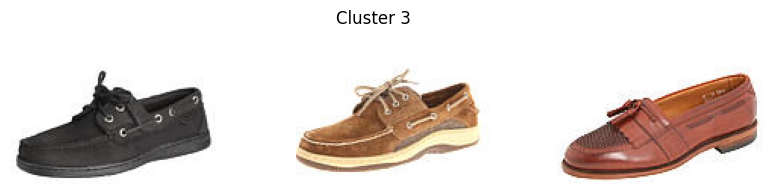

In [16]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def cluster_representative(cluster_id, cluster_ids, paths, n=3):
    # cluster_id: particularly which cluster image to represent
    # cluster_ids: available cluster_ids
    # paths: image root path
    # n: no of representative to be shown
    idxs = [i for i,c in enumerate(cluster_ids) if c == cluster_id]
    selected = random.sample(idxs, min(n, len(idxs))) # selected samples

    plt.figure(figsize=(10,2)) # plotting figure size

    for i, idxs in enumerate(selected):
        img = Image.open(paths[idxs]) # representative image
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.axis("off") # not having axis
    
    plt.suptitle(f"Cluster {cluster_id}")
    plt.show()


cluster_representative(cluster_id = 3, cluster_ids=cluster_ids, paths=paths, n=3)


**For 3D visualization**

In [ ]:
# # DON'T RUN TWICE
# # for 3D visualization stuffs

# embeddings_3D = reducer_3D.fit_transform(embeddings.cpu().numpy()) # embeddings into 3D

# np.save("embeddings_3D.npy", embeddings_3D) # for 3D plotting
# pickle.dump(reducer_3D, open("umap_3D.pkl", "wb")) # saving umap_3D


c:\Users\USER\simsearch\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<module 'matplotlib.pyplot' from 'c:\\Users\\USER\\simsearch\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

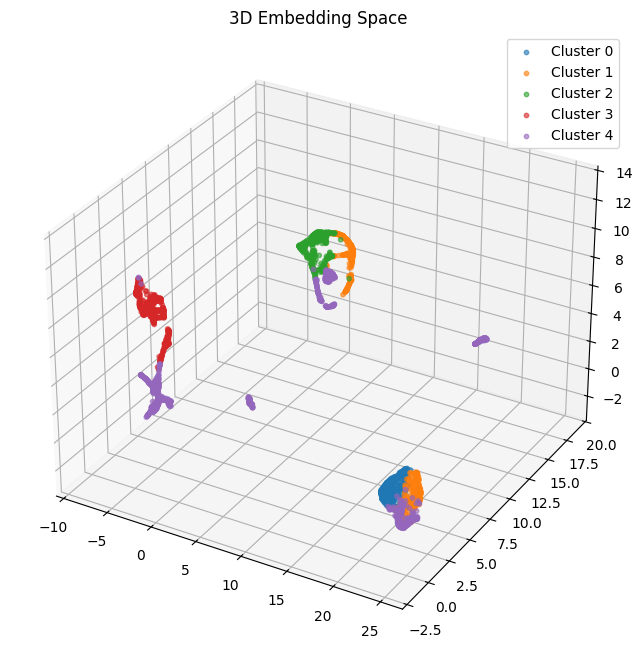

In [18]:
# basic 3D plot
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np


def plot_3d_clusters(embeddings_3D, cluster_ids):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    cluster_ids = np.array(cluster_ids)
    unique_ids = np.unique(cluster_ids)

    for id in unique_ids:
        idx = cluster_ids == id

        ax.scatter(
            embeddings_3D[idx, 0],
            embeddings_3D[idx, 1],
            embeddings_3D[idx, 2],
            label=f"Cluster {id}",
            alpha=0.6,
            s=10
        )

    ax.set_title("3D Embedding Space")
    ax.legend()

    return plt

embeddings_3D = np.load("embeddings_3D.npy")
plot_3d_clusters(embeddings_3D=embeddings_3D, cluster_ids = cluster_ids)


*Interactive 3D plot*

In [19]:
import plotly.express as px
import pandas as pd
import numpy as np


def plot_3d_interactive(embeddings_3D, cluster_ids):
    df = pd.DataFrame({
        "x": embeddings_3D[:, 0],
        "y": embeddings_3D[:, 1],
        "z": embeddings_3D[:, 2],
        "label": cluster_ids
    })

    fig = px.scatter_3d(
        df,
        x="x",
        y="y",
        z="z",
        color="label",
        opacity=0.7,
        title="3D Embedding Clusters"
    )

    fig.update_traces(marker=dict(size=4))

    fig.show()


embeddings_3D = np.load("embeddings_3D.npy")
plot_3d_interactive(embeddings_3D=embeddings_3D, cluster_ids=cluster_ids)


*for a given query image, placing it into a cluster automatically*